# 💼 Employee Salary Prediction



### Step 1 — Import Libraries
**What happens here:** we load all the Python libraries needed for data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), preprocessing/modeling (`scikit-learn`), and model persistence (`joblib`).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_style("whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


### Step 2 — Load the Dataset
**Where you are:** the very start of the pipeline — getting raw data into the notebook.
**What happens here:** for demonstration we generate a realistic **synthetic** salary dataset so this notebook runs end-to-end without external files. To use your own data instead, replace the generated `df` with:
```python
df = pd.read_csv("Salary_Data.csv")
df.head()
```

In [3]:
np.random.seed(42)
n = 1000

experience = np.random.randint(0, 25, n)
education = np.random.choice(["High School", "Bachelors", "Masters", "PhD"], n, p=[0.15, 0.45, 0.30, 0.10])
job_role = np.random.choice(["Analyst", "Developer", "Manager", "Designer", "Data Scientist"], n)
location = np.random.choice(["Tier-1 City", "Tier-2 City", "Tier-3 City"], n, p=[0.5, 0.35, 0.15])
company_size = np.random.choice(["Small", "Medium", "Large"], n, p=[0.3, 0.4, 0.3])

edu_bonus = {"High School": 0, "Bachelors": 8000, "Masters": 16000, "PhD": 25000}
role_bonus = {"Analyst": 0, "Developer": 10000, "Manager": 22000, "Designer": 5000, "Data Scientist": 18000}
loc_bonus = {"Tier-1 City": 12000, "Tier-2 City": 5000, "Tier-3 City": 0}
size_bonus = {"Small": 0, "Medium": 6000, "Large": 14000}

salary = (
    30000
    + experience * 1800
    + np.array([edu_bonus[e] for e in education])
    + np.array([role_bonus[r] for r in job_role])
    + np.array([loc_bonus[l] for l in location])
    + np.array([size_bonus[s] for s in company_size])
    + np.random.normal(0, 4000, n)
)

df = pd.DataFrame({
    "Experience": experience,
    "Education": education,
    "JobRole": job_role,
    "Location": location,
    "CompanySize": company_size,
    "Salary": salary.round(2)
})

df.head()

,Experience,Education,JobRole,Location,CompanySize,Salary
0,6,Bachelors,Data Scientist,Tier-2 City,Medium,79539.08
1,19,Bachelors,Designer,Tier-1 City,Medium,97101.72
2,14,Bachelors,Developer,Tier-2 City,Large,89017.77
3,10,Bachelors,Designer,Tier-1 City,Small,74697.58
4,7,Bachelors,Analyst,Tier-1 City,Medium,73718.07


### Step 3 — Explore the Data (EDA)
**Where you are:** right after loading data, before any cleaning.
**What happens here:** we inspect structure, types, summary statistics, and check for missing values to decide what cleaning is needed.

In [4]:
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Experience   1000 non-null   int32  
 1   Education    1000 non-null   object 
 2   JobRole      1000 non-null   object 
 3   Location     1000 non-null   object 
 4   CompanySize  1000 non-null   object 
 5   Salary       1000 non-null   float64
dtypes: float64(1), int32(1), object(4)
memory usage: 43.1+ KB
None

Missing values per column:
 Experience     0
Education      0
JobRole        0
Location       0
CompanySize    0
Salary         0
dtype: int64


,Experience,Salary
count,1000.000000,1000.000000
mean,11.991000,87205.953470
std,7.443946,18872.525626
min,0.000000,32224.830000
25%,5.000000,73723.657500
50%,12.000000,87212.720000
75%,18.250000,100813.840000
max,24.000000,140072.780000


**Visualize relationships** between Experience and Salary, and Salary distribution by Job Role.

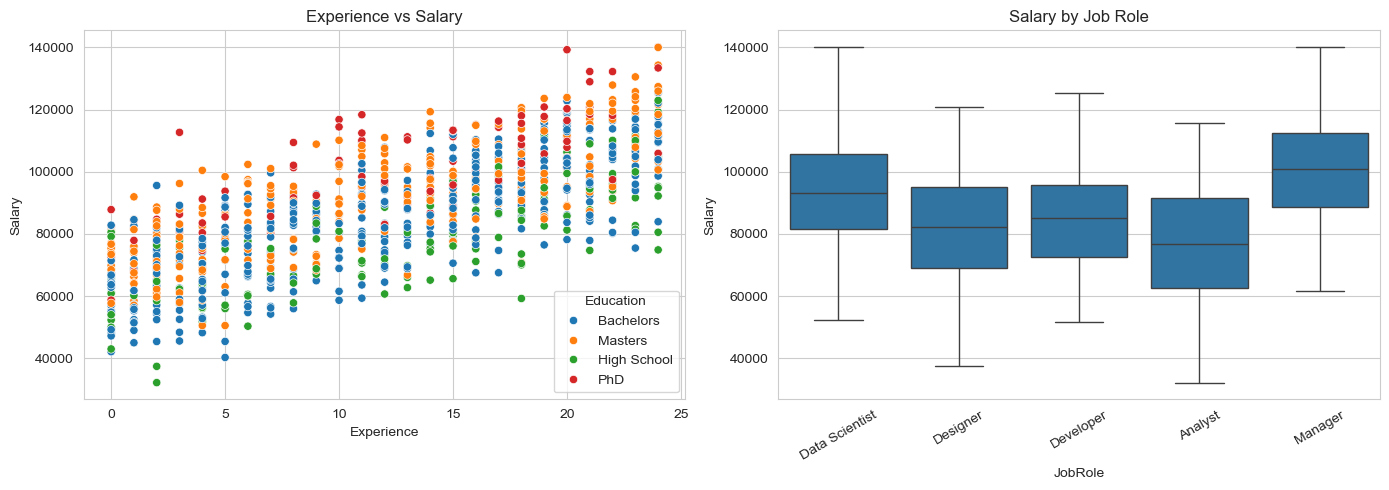

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Experience", y="Salary", hue="Education", ax=axes[0])
axes[0].set_title("Experience vs Salary")

sns.boxplot(data=df, x="JobRole", y="Salary", ax=axes[1])
axes[1].set_title("Salary by Job Role")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### Step 4 — Data Cleaning
**Where you are:** after EDA, before encoding.
**What happens here:** handle missing values (if any) and remove obvious outliers/duplicates. Our synthetic data is clean, but this is where real-world messy data gets fixed.

In [6]:
df = df.drop_duplicates()
df = df.dropna()
print("Shape after cleaning:", df.shape)

Shape after cleaning: (1000, 6)


### Step 5 — Encode Categorical Features
**Where you are:** preparing features for the model.
**What happens here:** `Education` has a natural order, so we use ordinal encoding; `JobRole`, `Location`, and `CompanySize` are one-hot encoded since they have no inherent order.

In [7]:
education_order = {"High School": 0, "Bachelors": 1, "Masters": 2, "PhD": 3}
df["Education"] = df["Education"].map(education_order)

df_encoded = pd.get_dummies(df, columns=["JobRole", "Location", "CompanySize"], drop_first=True)
df_encoded.head()

,Experience,Education,Salary,JobRole_Data Scientist,JobRole_Designer,JobRole_Developer,JobRole_Manager,Location_Tier-2 City,Location_Tier-3 City,CompanySize_Medium,CompanySize_Small
0,6,1,79539.08,True,False,False,False,True,False,True,False
1,19,1,97101.72,False,True,False,False,False,False,True,False
2,14,1,89017.77,False,False,True,False,True,False,False,False
3,10,1,74697.58,False,True,False,False,False,False,False,True
4,7,1,73718.07,False,False,False,False,False,False,True,False


### Step 6 — Split Features & Target, Then Train/Test Split
**Where you are:** right before modeling.
**What happens here:** separate input features (`X`) from the target (`Salary`), then split into training (80%) and test (20%) sets so we can fairly evaluate the model later.

In [8]:
X = df_encoded.drop("Salary", axis=1)
y = df_encoded["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (800, 10)  Test size: (200, 10)


### Step 7 — Feature Scaling
**Where you are:** just after splitting (scaler is fit on train only, to avoid data leakage).
**What happens here:** standardize numeric features so models like Linear Regression aren't biased by differing feature scales.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 8 — Build & Train Models
**Where you are:** the core modeling step.
**What happens here:** train a simple baseline (Linear Regression) and a more flexible model (Random Forest) so we can compare performance.

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)  # tree models don't need scaling

print("Models trained.")

Models trained.


### Step 9 — Evaluate Models
**Where you are:** right after training, before tuning.
**What happens here:** compute MAE, RMSE, and R² on the test set for both models and compare them side-by-side.

In [11]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | R2: {r2:.3f}")
    return mae, rmse, r2

lr_preds = lr_model.predict(X_test_scaled)
rf_preds = rf_model.predict(X_test)

evaluate("Linear Regression", y_test, lr_preds)
evaluate("Random Forest", y_test, rf_preds)

Linear Regression -> MAE: 3,070.42 | RMSE: 3,879.20 | R2: 0.960
Random Forest -> MAE: 4,972.13 | RMSE: 6,192.00 | R2: 0.898


(4972.133521503568, np.float64(6191.997548752696), 0.8984267656237092)

### Step 10 — Hyperparameter Tuning (Random Forest)
**Where you are:** improving the better-performing model from Step 9.
**What happens here:** use `GridSearchCV` to search over a small grid of Random Forest hyperparameters and pick the best combination via cross-validation.

In [12]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

best_preds = best_rf.predict(X_test)
evaluate("Tuned Random Forest", y_test, best_preds)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest -> MAE: 4,972.13 | RMSE: 6,192.00 | R2: 0.898


(4972.133521503568, np.float64(6191.997548752696), 0.8984267656237092)

### Step 11 — Predict on a New Sample
**Where you are:** using the final trained model in a realistic scenario.
**What happens here:** build one new employee record and get a predicted salary, the same way a real application would call the model.

In [13]:
sample = pd.DataFrame({
    "Experience": [5],
    "Education": [education_order["Masters"]],
    "JobRole_Developer": [1],
    "JobRole_Manager": [0],
    "JobRole_Designer": [0],
    "JobRole_Data Scientist": [0],
    "Location_Tier-2 City": [0],
    "Location_Tier-3 City": [0],
    "CompanySize_Medium": [1],
    "CompanySize_Large": [0],
})

# Ensure sample has exactly the same columns/order as training data
sample = sample.reindex(columns=X.columns, fill_value=0)

predicted_salary = best_rf.predict(sample)
print(f"Predicted Salary: {predicted_salary[0]:,.2f}")

Predicted Salary: 80,054.56


### Step 12 — Save the Final Model
**Where you are:** end of the pipeline.
**What happens here:** persist the trained model (and scaler, if needed for other models) to disk with `joblib`, so it can be loaded later in an app without retraining.

In [14]:
joblib.dump(best_rf, "salary_prediction_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Model and scaler saved to disk.")

Model and scaler saved to disk.
